# Visualizing Housing Data

## Introduction

> ❓ **Why can't we just trust the summary statistics from Lesson 1?**
>
> In Lesson 1, `.describe()` told us the mean price was around $115,000. But that
> number hides everything: the shape of the distribution, the location of outliers,
> whether price and area are linearly related, and whether location changes the
> story entirely. Numbers summarize; visualizations *reveal*. This lesson teaches
> the three plot types that every data scientist uses before running a single model.

In Lesson 1, we loaded, cleaned, and concatenated three CSV files into a single
tidy dataset, and computed our first descriptive statistics. We saw a hint of right
skew — the mean was higher than the median — but we could not see the distribution
shape. We could not see where the outliers were. We could not see whether the
relationship between property size and price was linear, curved, or noisy. We could
not see whether location changes that relationship entirely.

**Visualization is the bridge** between raw statistics and genuine understanding.
Every plot in this lesson is motivated by a specific question that numbers alone
cannot answer.

**Research Question:** Are property prices in Mexico more influenced by property
size or by location?

By the end of this lesson, you will have built all the visual evidence you need to
form an initial, data-driven hypothesis before the formal correlation analysis in
Lesson 3.

**By the end of this notebook you will be able to:**

- Explain the difference between **Matplotlib's explicit (object-oriented) and
  implicit (pyplot) interfaces** and choose the explicit interface for all
  professional plotting
- Build and interpret **histograms** to see distribution shape, detect skewness,
  and reason about what the tail of a distribution implies
- Build and interpret **boxplots** (box-and-whisker plots) including all five
  summary statistics: minimum, Q1, median, Q3, maximum, and flagged outlier dots
- Build **scatterplots** to visualize the relationship between two numerical
  variables and identify patterns, noise, and compression from outliers
- Apply **quantile-based outlier removal** to strip extreme values from both
  axes before visual analysis
- Add a **regression trendline** using `seaborn.regplot()` and interpret the
  confidence band width alongside the slope
- Use **`.groupby()`** as the split-apply-combine engine for computing
  per-group statistics and producing grouped visualizations
- Create **small multiples** — a grid of plots, one per category — to compare
  how relationships differ across locations

## 1. Setup and Data Loading

First, let's import our libraries and load the clean dataset we created
in Lesson 1: `"./data/mexico-real-estate-combined-clean.csv"`.

**Code Task 1.2.1.1**


In [4]:
import pandas as pd

# Define the path to the clean CSV file saved in Notebook 1
data_path = "./data/mexico-real-estate-combined-clean.csv"

# Load the data
df = pd.read_csv(data_path)

# Verify the load
print(f"Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.")
print(df.info())
df.head()

Dimensions: 1736 rows and 6 columns.
<class 'pandas.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  1736 non-null   str    
 1   state          1736 non-null   str    
 2   lat            1736 non-null   float64
 3   lon            1736 non-null   float64
 4   area_m2        1736 non-null   float64
 5   price_usd      1736 non-null   float64
dtypes: float64(4), str(2)
memory usage: 112.8 KB
None


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


> 📊 **After loading — verify the data is intact**
>
> Confirm that `.info()` shows:
> - Six columns: `property_type`, `state`, `lat`, `lon`, `area_m2`, `price_usd`
> - `price_usd` dtype is `float64` (not `object`) — confirming the L1 cleaning succeeded
> - Zero non-null gaps — all 1,700+ rows are complete
>
> If `price_usd` shows `object` here, the file was not saved correctly in L1. Go
> back and re-run L1's `df.to_csv(...)` cell, then reload here.

## 2. Univariate Analysis: Understanding One Variable at a Time

Before we look for *relationships* between variables, we must understand each
variable *individually*. This is called **univariate analysis** — analysis of one
variable at a time.

> 🎯 **Why visualize before computing correlations?**
>
> Anscombe's Quartet (1973) is a famous dataset consisting of four groups of data
> that have identical summary statistics — the same mean, variance, and correlation
> coefficient — but wildly different visual patterns (a linear relationship, a
> curve, a cluster with one outlier, and a vertical line with one outlier). The
> lesson: *summary statistics are necessary but not sufficient*. Always plot first.
>
> For our housing dataset specifically:
>
> | Question | Cannot answer with numbers alone | Visualization that answers it |
> |---|---|---|
> | Is price symmetric or skewed? | `.describe()` hints at skew (mean > median) | Histogram — shows the actual shape |
> | Are there extreme outliers? | `max` gives one number | Histogram + Boxplot — show where outliers cluster |
> | Do prices differ by state? | State means could be computed | Boxplot by state — shows spread, not just center |
> | Is size-price relationship linear? | Correlation gives one number | Scatterplot — shows noise, curves, clusters |
> | Does location change the size-price relationship? | Segmented correlation is possible | Small multiples — three plots side by side |

We will answer these questions in order. We start with histograms to understand
the shape of the price and area distributions.

---


In [5]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1169843696", h="3298dbabb7", width=700, height=450) 

### The Plotting Library: Matplotlib

**What is Matplotlib?**

Matplotlib is the foundational plotting library for Python — the engine beneath
virtually every Python visualization you encounter. It creates static,
publication-quality figures. Most other Python visualization libraries (Seaborn,
Pandas plotting, Plotly's static mode) are built on top of it.

Understanding Matplotlib's architecture is not optional: it determines whether
your code is readable, debuggable, and reusable. The core concept is the
separation between a **Figure** (the canvas) and **Axes** (the actual plot area).

**The Two Interfaces: Why They Both Exist, and Which to Use**

Matplotlib provides two distinct ways to create plots. Both exist for historical
reasons; only one is appropriate for professional work.

#### 🚦 Implicit vs Explicit Interface — which to use?

| | Implicit (Pyplot style) | Explicit (Object-Oriented style) |
|---|---|---|
| **Entry point** | `import matplotlib.pyplot as plt` → `plt.plot(...)` | `fig, ax = plt.subplots()` → `ax.plot(...)` |
| **Mental model** | "State machine" — Matplotlib tracks a hidden "current figure" | You hold references to specific Figure and Axes objects |
| **Multi-plot control** | Gets complicated with multiple subplots | Natural — each `ax` is independent |
| **Seaborn/Pandas integration** | Partial | Full — pass `ax=ax` to any library |
| **Recommended for** | Quick one-off terminal exploration | All notebook code, all production code |

> ✅ **Always use the explicit (object-oriented) interface in this course and in
> professional work.**
>
> The implicit interface looks shorter for simple cases, but breaks down as soon
> as you add a second plot, pass axes to Seaborn, or write reusable code. The
> explicit interface has no such limitations.

**The explicit interface — a complete reference:**

```python
# Step 1: Create the canvas and the plot area
fig, ax = plt.subplots()

# Step 2: Draw on the specific axes object
ax.hist(df["price_usd"])       # or ax.scatter(), ax.plot(), ax.boxplot()

# Step 3: Label and customize using ax.set_* methods
ax.set_title("My Title")
ax.set_xlabel("X Axis Label")
ax.set_ylabel("Y Axis Label")
ax.set_xlim(0, 500000)         # Optional: fix axis range

# Step 4: Display
plt.tight_layout()  # Prevent labels from being cut off
plt.show()          # Render the figure
```

> 📌 **The `set_` prefix convention**
>
> In the explicit interface, customization methods use `set_` prefix: `set_title`,
> `set_xlabel`, `set_ylabel`, `set_xlim`, `set_ylim`. This is different from
> the implicit interface which uses `plt.title()`, `plt.xlabel()`, etc. (no `set_`).
> The `set_` convention is consistent with Python's broader property-setting pattern.

**The `fig, ax = plt.subplots()` return value:**

`plt.subplots()` returns a tuple of `(Figure, Axes)`. We immediately unpack this
into two variables named `fig` and `ax` — the standard convention. You can name
them anything, but using `fig` and `ax` is so universal that deviating will
confuse every reader.

**The `figsize` parameter:**

```python
fig, ax = plt.subplots(figsize=(10, 6))  # width=10 inches, height=6 inches
```

`figsize` controls the physical size of the canvas in inches. Larger `figsize`
gives higher resolution and more room for labels. Use it whenever labels are
getting cut off or the plot looks cramped.

**The pandas–Matplotlib connection:**

Pandas has a built-in `.plot()` method that is actually calling Matplotlib
internally. You can connect them explicitly:

```python
fig, ax = plt.subplots()            # Create the axes
df["price_usd"].plot(ax=ax)         # Pandas draws on our specific axes
ax.set_title("My Pandas Plot")      # We control the customization
```

This pattern — create `ax` first, pass `ax=ax` to a library — also works with
Seaborn, which we will use in §4.

### 2.1 Histograms

> 🎯 **What is a histogram, and what does it show?**
>
> A histogram divides the range of a numerical variable into **bins** (equal-width
> intervals) and counts how many observations fall into each bin. The height of each
> bar is the count (frequency) for that bin. The bars touch (unlike bar charts) to
> signal that the variable is *continuous* — there are no gaps in the data range.
>
> **What a histogram reveals:**
> - **Central tendency** — where most values cluster
> - **Spread** — how wide the distribution is
> - **Skewness** — whether the distribution has a long tail on one side
> - **Modality** — whether there is one peak (unimodal) or multiple peaks (bimodal)
> - **Outliers** — isolated bars far from the main cluster
>
> **Bins** — the number of bars — is a user-controlled parameter. Too few bins and
> the histogram is over-smoothed (loses detail). Too many bins and it is too jagged
> (over-fits the noise). The default (usually 10) is often a good starting point;
> adjust based on what the plot is communicating.

---

✅ You can take **Multiple Choice Question 1.2.2.1** & **Multiple Choice Question 1.2.2.2**

---

**Code 1.2.2.1** — Histogram of `price_usd`:


Matplotlib is building the font cache; this may take a moment.


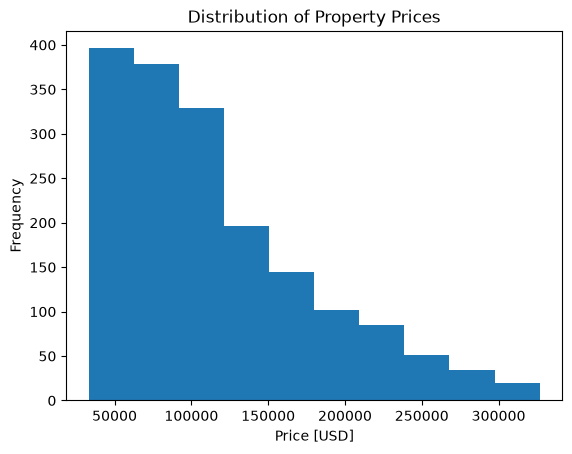

In [6]:
# import matplotlib
import matplotlib.pyplot as plt

# Create a histogram for price
fig, ax = plt.subplots()

# Create a histogram for price_usd
ax.hist(df["price_usd"])

# Add x-axis label, y-axis label & title
ax.set_xlabel("Price [USD]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Prices"); # The semi-colon is added to suppress some ugly text and just gives us the graphic.

> 📊 **Reading the `price_usd` histogram — right skew in housing data**
>
> **Shape:** The distribution is strongly **right-skewed** (positively skewed). The
> tallest bars are on the left — most properties are priced between 30,000 and
> 130,000. The distribution then tapers off slowly to the right, with a long thin
> tail of expensive properties extending to 300,000+.
>
> **"The tail tells the tale":** In statistics, skewness is measured by which side
> of the distribution has the longer tail. A right tail means a small number of
> high-value observations are pulling the mean above the median.
>
> **Why right skew is the norm in housing markets:**
> Property prices have a natural lower bound (no property costs zero or less) but
> effectively no upper bound (a luxury property can cost 100x the median). This
> asymmetry guarantees a right-skewed distribution in almost every real estate
> market.
>
> **Mean vs median in this histogram:**
> - The **median** (the 50th percentile) sits roughly at the histogram's peak —
>   around 95,000-100,000.
> - The **mean** is pulled rightward by the tail — roughly 115,000.
> - The 15,000-20,000 gap between them is the price of ignoring skewness.
>
> **Practical implication for our research question:**
> When comparing typical prices across states in Lesson 4, we will use the
> **median** rather than the mean. A single 300,000 luxury property in a small
> state could inflate that state's mean enough to make it look like an expensive
> market — even if most listings there are cheap.

### When does right skew matter for analysis?

Right skew is not just an interesting observation — it has concrete consequences
for every analytical decision you make downstream:

**1. Choosing a measure of center.** The mean and median diverge when distributions
are skewed. For our dataset, the mean price (~115,000) is roughly 15–20% higher
than the median (~97,000). If you used the mean to represent a "typical" property,
you would systematically overstate what most buyers pay. The median is more robust
because it is unaffected by the exact value of the extreme properties — it only
cares about the middle observation.

**2. Outlier sensitivity in models.** Any statistical model that minimizes squared
errors (including linear regression, which we will encounter in later lessons) is
particularly sensitive to right-skewed data. Squaring the error of a 300,000
outlier produces an enormous penalty that can pull the entire model toward that
one observation. Quantile-based filtering (which we apply in §4.2) partially
addresses this by trimming the extreme tail before modeling.

**3. Log transformation.** A common technique for right-skewed price data is to
take the natural logarithm (`np.log(df["price_usd"]`). The log of a right-skewed
distribution is often approximately normal (bell-shaped). This matters because
many statistical tests assume normality. We will not apply a log transformation
in this course, but knowing it exists is important: if you were building a
production pricing model, you would almost certainly model `log(price)` rather
than raw `price`.

**4. Visualization choices.** Right skew makes histogram bins uneven in visual
weight — most of the information is in the left cluster, but the axis must extend
far to the right to accommodate the tail. This is why we trim outliers before
building scatterplots.

---

✅ You can take **Multiple Choice Question 1.2.2.3**

---

**Code 1.2.2.2** — Histogram of `area_m2`:


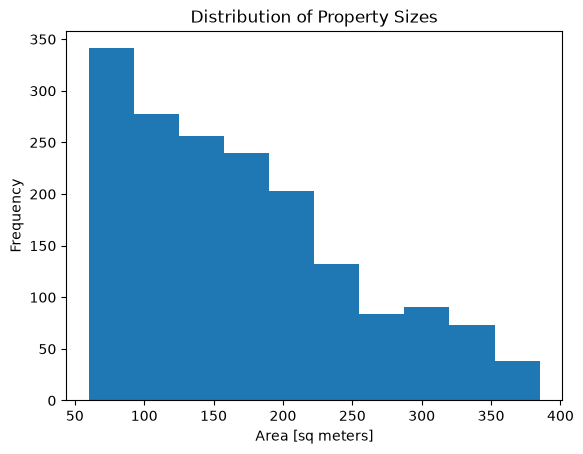

In [7]:
# Create a histogram for area_m2
fig, ax = plt.subplots()

# Use Matplotlib to create histogram of "area_m2"
ax.hist(df["area_m2"])

# Add x-axis label, y-axis label & title
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Sizes");

> 📊 **Reading the `area_m2` histogram — size distribution and what it implies**
>
> **Shape:** Also right-skewed, but for a different reason. Most properties in the
> dataset are apartments or smaller houses (50–150 m²), with a long tail of larger
> properties (mansions or commercial listings that crept into the dataset).
>
> **Comparing the two histograms:**
>
> | Variable | Peak (mode) | Right tail | Implication |
> |---|---|---|---|
> | `price_usd` | ~60,000–80,000 | Long — extends to the most expensive listing | A few luxury properties inflate the mean |
> | `area_m2` | ~80–120 m² | Long — extends to the largest listing | A few large properties inflate the mean |
>
> **Why both are right-skewed:** Both price and area have a physical lower bound
> (a property must have positive size and a positive price) but no mathematical
> upper bound. Any variable with a hard floor but no ceiling tends to be
> right-skewed.
>
> **What this means for size-price analysis:**
> If we correlate raw `area_m2` with raw `price_usd`, the handful of extreme
> outliers (a 800 m² mansion at $300,000) will dominate the relationship and
> misrepresent the typical market. We will need to remove these before any
> scatterplot or correlation analysis — which we do in §4.2.
>
> **Comparing price and area distributions side by side:**
>
> | Feature | `price_usd` | `area_m2` |
> |---|---|---|
> | Distribution shape | Right-skewed | Right-skewed |
> | Typical center (median) | ~97,000 | ~100 m² |
> | Mean vs median gap | ~15–20% above | ~20–30% above |
> | Severity of right tail | Moderate (2–3× median) | Severe (8–10× median possible) |
> | Primary cause of skew | Luxury properties | Large estates / data errors |
> | Impact on correlation | Outliers inflate r | Outliers compress the scatterplot |
>
> **A key difference between the two tails:** The `price_usd` tail, while long, is
> clearly part of the real estate market — luxury properties genuinely exist and
> trade at multiples of the median. The `area_m2` tail is more suspect: an unusually
> large listing in a residential dataset may represent a data entry error, a commercial
> property, or a rural land parcel that should not be in a housing analysis. This is
> why we apply the same quantile filter to area as to price — the area outliers may
> not just be unusual, they may be wrong.

## 3. Bivariate Analysis: Categorical vs. Numerical

Now that we understand each variable individually, we move to **bivariate analysis**
— studying the relationship between two variables simultaneously. We start by
comparing a numerical variable (`price_usd`) against a categorical variable
(`property_type`, `state`). The right tool for this is the boxplot.


In [8]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1169843401", h="3298dbabb7", width=700, height=450)

### Boxplots: Five Numbers in One Chart

> ❓ **Why use a boxplot when you already have a histogram?**
>
> A histogram shows the full shape of one variable's distribution. A boxplot
> compresses that same distribution into five summary numbers — making it ideal
> for *comparing multiple groups side by side*. A histogram of 20 states would
> be unreadable; twenty boxplots in a row are perfectly clear.

**Formal definition: the five-number summary**

A boxplot is a visual representation of the **five-number summary**:

> 📌 **Anatomy of a boxplot**
>
> ```
>     |          ┌────────┬────────┐          |   •  •
>     ───────────┤        │        ├──────────────
>     |          └────────┴────────┘          |
>     ↑          ↑        ↑        ↑          ↑   ↑
>    Min        Q1      Median    Q3         Max Outliers
>  (or fence)                             (or fence)
> ```
>
> | Element | What it is | Statistical name |
> |---|---|---|
> | Left edge of box | 25th percentile — 25% of observations are below this | Q1 (first quartile) |
> | Line inside box | 50th percentile — the middle value | Q2 (median) |
> | Right edge of box | 75th percentile — 75% of observations are below this | Q3 (third quartile) |
> | Box width | Q3 − Q1 = the range of the middle 50% of observations | IQR (Interquartile Range) |
> | Left whisker | Extends to the smallest value within 1.5 × IQR of Q1 | Lower fence |
> | Right whisker | Extends to the largest value within 1.5 × IQR of Q3 | Upper fence |
> | Individual dots beyond whiskers | Observations outside the fences — statistical outliers | Outliers |

**How to read a boxplot:**

- **Box width (IQR):** A wide box means high variability in the middle 50%.
  A narrow box means tight clustering.
- **Median line position:** Is the median close to the center of the box, or
  pushed toward one edge? A median pushed to the left (closer to Q1) indicates
  right skew within the middle 50%.
- **Whisker lengths:** Unequal whiskers confirm asymmetry. A long right whisker
  means the upper half of the non-outlier data is more spread out.
- **Outlier dots:** A long string of dots on one side signals a heavy tail. For
  housing prices, we almost always see dots on the right (expensive properties).

> ⚠️ **What a boxplot hides:** Because it summarizes the distribution into five
> numbers, a boxplot cannot show you *how* values are distributed between Q1 and
> Q3. A bimodal distribution (two peaks) would look identical to a uniform one
> in a boxplot. For shape, you still need the histogram. For comparison, the
> boxplot is king.


### 3.1 Comparing Property Types

**Code Task 1.2.3.1**: Create a horizontal boxplot of `"price_usd"` by
`"property_type"`. The x-axis should have the label `"Price [USD]"` and the
plot the title `"Price Distribution by Property Type"`.

> 💡 **Why horizontal?** Setting `vert=False` rotates the boxplot so that the
> numerical axis (price) runs left-to-right. This matches our intuitive mental
> model of a number line and makes it easier to read price values directly off
> the x-axis. For categorical comparisons where the categories have long names,
> horizontal is almost always better.


C:\Users\muhds\AppData\Local\Temp\ipykernel_28620\3605743836.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_type, tick_labels=prop_types, vert=False)


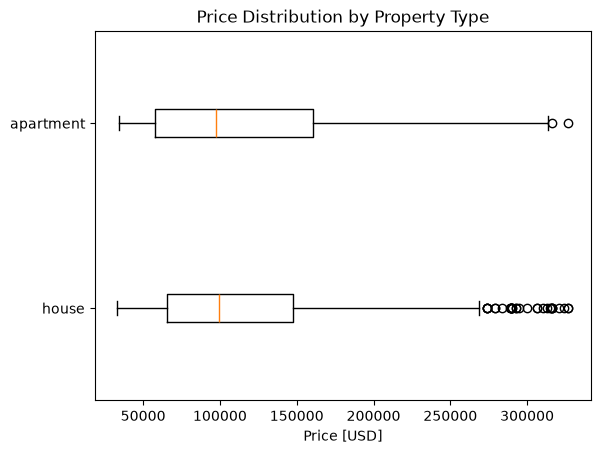

In [10]:
# 1. Get the unique category names on the column "property_type"
prop_types = df["property_type"].unique()

# 2. Prepare the data: Create a list of price arrays, one for each type
data_by_type = [df[df["property_type"] == label]["price_usd"] for label in prop_types]

# 3. Plot
fig, ax = plt.subplots()

# Pass the data list and the labels list
ax.boxplot(data_by_type, tick_labels=prop_types, vert=False)

ax.set_title("Price Distribution by Property Type")
ax.set_xlabel("Price [USD]")


plt.show() # plt.show() acts as the semi-colon, to suppress some ugly text and just give us the graphic.

> 📊 **Reading the property-type boxplot — what the five-number summary reveals**
>
> Apply the anatomy from above:
>
> **Houses:**
> - Read the median line and the two box edges off your own plot: they give you the
>   typical house price and the range covered by the middle 50% of listings.
> - Notice the **string of outlier dots on the right** — expensive houses extending
>   well past the upper fence. These are the luxury single-family homes that drive
>   the right skew we saw in the histogram.
>
> **Apartments:**
> - The median line sits close to the one for houses, confirming that the *typical*
>   price for both property types is similar.
> - The outlier tail is smaller: fewer dots sit beyond the upper fence.
>
> ⚠️ **A smaller outlier tail does not mean a shorter whisker.** These are two
> separate features and they often move in opposite directions. The whisker stops at
> the last observation *inside* the 1.5 × IQR fence, so where it lands depends on the
> width of the box and on where the data happen to sit. A group whose extreme values
> get flagged as individual outlier dots can end up with a *shorter* whisker than a
> group with almost no dots at all. Compare the two features separately on your own
> plot rather than expecting them to agree.
>
> **Key insight:** The similar medians might lead you to conclude that property
> type does not affect price. **But this is misleading.** Houses and apartments
> have similar *total* prices, but apartments are smaller. In Lesson 4 we will
> compute `price_per_m2` — price per square meter — and the story changes
> dramatically: apartments are significantly more valuable per unit area.

**How to read a boxplot — a checklist:**

Use this checklist every time you encounter a boxplot to ensure you extract all
the information it contains:

- **Step 1 — Find the median line.** The vertical line inside the box is the 50th
  percentile. This is your measure of center. Compare the medians across groups
  first — this is usually the headline finding.

- **Step 2 — Assess the IQR (box width).** The box spans from Q1 to Q3. A wider
  box means more variability in the middle 50% of the group. If one group's box is
  twice as wide as another's, that group has much more internal price diversity.

- **Step 3 — Check median position within the box.** If the median line sits
  close to the center of the box, the distribution is roughly symmetric. If it
  sits closer to Q1 (left edge), the distribution is right-skewed within the
  middle 50%. If closer to Q3, it is left-skewed.

- **Step 4 — Compare whisker lengths.** Unequal whiskers indicate asymmetry in
  the non-outlier tails. A long right whisker and short left whisker is another
  signature of right skew — the upper non-outlier data is more spread out.

- **Step 5 — Count and position the outlier dots.** Isolated dots beyond the
  whiskers are statistically flagged as outliers (beyond 1.5 × IQR from the box
  edges). A long string of dots on the right indicates a heavy upper tail. A single
  isolated dot very far from the others may be a data error worth investigating.

---

✅ You can take **Multiple Choice Question 1.2.3.1**

---

### 3.2 Comparing States

**Code Task 1.2.3.2**: Create a similar horizontal boxplot of `"price_usd"` by
selected major states. Use the top 3 states by listing count.


C:\Users\muhds\AppData\Local\Temp\ipykernel_28620\81081373.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_state, tick_labels=selected_states, vert=False)


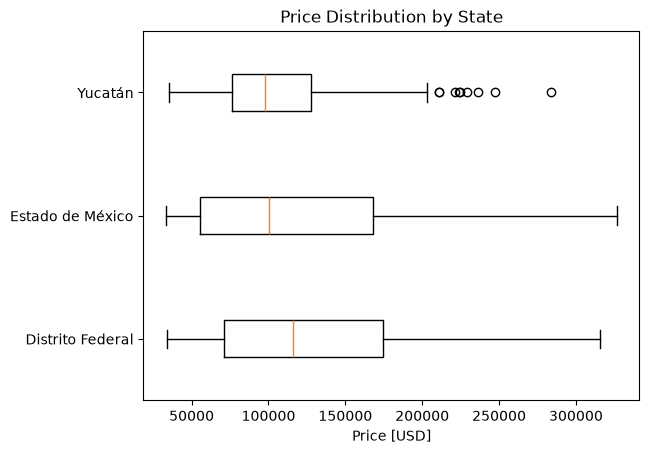

In [11]:
# 1. Define your selected states
selected_states = (
    df["state"]
    .value_counts()
    .head(3)
    .index.tolist()
)
# 2. Prepare the data
data_by_state = [df[df["state"] == state]["price_usd"] for state in selected_states]

# 3. Plot
fig, ax = plt.subplots()

# FIX: Use 'tick_labels' instead of 'labels'
ax.boxplot(data_by_state, tick_labels=selected_states, vert=False)

ax.set_title("Price Distribution by State")
ax.set_xlabel("Price [USD]")
plt.show()

> 📊 **Reading the states boxplot — location as a price driver**
>
> Three states, three very different stories:
>
> **Distrito Federal:**
> - The highest median of the three — Mexico's capital commands a premium.
> - A long right whisker: the ordinary market reaches well above the median, which
>   is what you expect from a market running from modest apartments to premium
>   penthouses.
>
> **Estado de México:**
> - A lower median than Distrito Federal but a comparable upper range — the long
>   right whisker captures high-value suburban properties close to the capital.
>
> **Yucatán:**
> - The lowest median and the narrowest box — the most affordable and the most
>   consistent market. Most listings are similarly priced.
> - A visible chain of outlier dots to the right — a distinct luxury segment
>   (resort-style properties?) that lives well outside the main market.
>
> **Compare the box widths yourself.** The state with the widest box is the one whose
> middle 50% of prices covers the largest range, and it is *not* necessarily the one
> with the highest median. Rank the three boxes by width on your own plot before
> reading on.
>
> ⚠️ **A long whisker and a trail of outlier dots are separate features, and a
> group can show one without the other.** The whisker reaches the last observation
> inside the 1.5 × IQR fence, so a wide box pushes that fence outward and absorbs
> values that a narrower box would have flagged as dots. Do not assume that the
> state with the most expensive properties is the one showing the most dots.
>
> **What this bivariate visualization proves:**
> Even without any formal statistics, the boxplot shows that **location matters**.
> Two properties with the same square footage — one in Distrito Federal, one in
> Yucatán — would likely sell at very different prices. This is the "location
> effect" we will quantify in Lesson 4.

**Geographic market segmentation — understanding what state-level differences mean:**

The variation across states in this boxplot is not just a statistical pattern — it
reflects the real-world process of **geographic market segmentation**. In real
estate and retail economics, market segmentation refers to the division of a broad
market into distinct sub-markets that behave according to different rules.

The three states shown in the boxplot represent three distinct market segments:

**Capital market (Distrito Federal):** Urban, dense, and globally connected. Prices
are driven by proximity to employment centers, transit access, and urban amenities.
The spread of prices reflects the internal diversity of Mexico City: world-class
neighborhoods coexist with working-class districts within the same administrative
boundary. Listing price has a high ceiling because the demand for premium urban
space is nearly unlimited.

**Peri-urban market (Estado de México):** This state surrounds Distrito Federal
and captures the "spillover" demand from the capital — families and businesses that
are priced out of the city proper. Prices are lower but influenced by commuting
distance and accessibility to DF, so this market is shaped by a different driver
than the neighbourhood mix that differentiates prices inside the capital.

**Regional/resort market (Yucatán):** The tightest price distribution indicates
a more homogeneous market — most listings are aimed at a similar buyer profile
(retirees, domestic tourism, local middle class). The luxury outliers likely
represent resort-adjacent properties near the coast.

**Why this matters for the research question:** If we want to know whether size or
location drives price, the state-level segmentation is the key evidence. The next
step — small multiples in 5 — will show whether the *slope* of the size-price
relationship also differs across these segments, or whether it is only the
*intercept* (the price level) that changes.

## 4. Bivariate Analysis: Numerical vs. Numerical

The core of our research question is the relationship between size and price. Does
a bigger property always cost more? Is the relationship consistent, or does it
vary by location?

### 4.1 Scatterplots

> 🎯 **What a scatterplot shows**
>
> A scatterplot maps two numerical variables against each other. Each point
> represents one observation — in our case, one property listing:
> - **Horizontal position (x-axis):** one variable (area in m²)
> - **Vertical position (y-axis):** another variable (price in USD)
>
> **What to look for:**
> - **Direction:** Does the cloud of points slope upward (positive relationship)
>   or downward (negative relationship)?
> - **Strength:** Are the points tightly packed around an imaginary line (strong
>   relationship) or widely scattered (weak relationship)?
> - **Form:** Is the relationship linear (straight line) or curved (non-linear)?
> - **Outliers:** Individual points far from the main cloud.

**Code 1.2.4.1** — Scatterplot of area vs price:


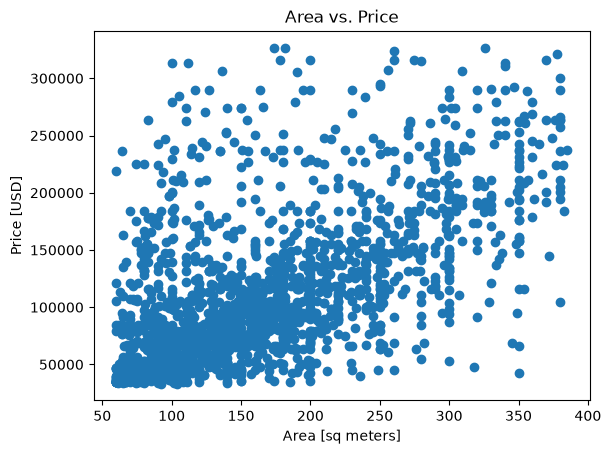

In [12]:
# 1. Create the Figure and Axes objects
fig, ax = plt.subplots()

# 2. Plot on the specific axes object
ax.scatter(x=df["area_m2"], y=df["price_usd"])

# 3. Set labels and title (Note the "set_" prefix)
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price")

plt.show()

> 📊 **Reading the raw scatterplot — compression from outliers**
>
> Look at where the points sit. Most of them crowd toward the lower left, while a
> thinner tail of larger and more expensive properties stretches to the right and
> upward. This is the signature of outliers **compressing the visualization**.
>
> **What "compression" means:** matplotlib scales each axis to the full range of the
> column, so the largest listing in the file sets the x-axis limit for every other
> point. The wider the gap between the largest value and the typical one, the more
> the dense region gets squeezed into a corner and the harder it becomes to read the
> relationship inside it.
>
> ⚠️ **How strong this effect is depends entirely on the tail of your own data.**
> Compare the axis limits against the range where the bulk of the points sit. If the
> largest listing is only moderately above the typical one, the compression will be
> mild and the cleaned plot in the next section will differ from this one in a subtle
> way rather than a dramatic one. Judge it by the axis limits, not by first
> impression.
>
> **What we cannot tell from this plot:**
> - Whether the relationship is linear or curved (the compression hides it)
> - How strong the relationship is (the main cluster is one indistinct blob)
> - Whether the slope is consistent across different price ranges
>
> ➡️ This is why **quantile-based outlier removal** is the next step — not to
> "cheat" the data, but to make the main market pattern visible.


### 4.2 Handling Outliers: Quantile-Based Filtering

> ❓ **Why remove outliers, and why use quantiles rather than a fixed cutoff?**

**The problem:** A handful of extreme properties — an unusually large plot, a
top-of-market penthouse — compress the scatterplot, so the pattern for the other 90%
of listings becomes harder to read. Beyond visualization, outliers cause mathematical
problems: any linear regression line will be pulled toward the extremes, misrepresenting
the typical market.

**Why not a fixed cutoff?** Removing properties above $250,000 might work for this
dataset — but what about the next dataset, where the price range is different? A
**quantile-based cutoff** adapts to the data: the 90th percentile is always "the
value above which 10% of observations lie," regardless of whether prices are in USD,
MXN, or EUR, or whether the dataset has 100 rows or 100,000 rows.

> 📌 **What is a quantile / percentile?**
>
> The **Nth percentile** of a distribution is the value below which N% of
> observations fall:
>
> | Percentile | Also called | Meaning |
> |---|---|---|
> | 25th | Q1 (first quartile) | 25% of observations are below this value |
> | 50th | Median / Q2 | 50% are below — the middle value |
> | 75th | Q3 (third quartile) | 75% are below |
> | 90th | — | 90% are below — our upper cutoff |
> | 5th | — | 5% are below — our lower cutoff |
>
> In pandas: `df["price_usd"].quantile(0.90)` returns the value at the 90th
> percentile. `df["price_usd"] < df["price_usd"].quantile(0.90)` creates a boolean
> mask that is `True` for the lower 90% of prices.

**Why asymmetric cuts (bottom 5%, top 10%)?**

We remove the bottom 5% but the top 10%, and that asymmetry is intentional:

> 💡 **The rule for asymmetric quantile cuts:** In real estate, the upper tail is
> far longer and more extreme — a handful of luxury properties can drag the
> trendline off course — while the lower end is less distorting. The bottom 5% cut
> removes potential data errors (properties listed at implausibly low prices: $500).
> The top 10% cut removes the luxury outliers that don't follow the "normal market"
> pattern. **Look at each tail separately and cut where the data tells you to, not
> out of habit.**

We apply the upper quantile cut to **both** `price_usd` and `area_m2`:
- An implausibly large plot is almost certainly a data error.
- Even if it is real, it compresses the entire x-axis, hiding the pattern for the
  other 95% of listings.

**Code 1.2.4.2** — Quantile-based outlier removal:


Original: 1736 rows
Cleaned: 1365 rows
Removed: 371 rows


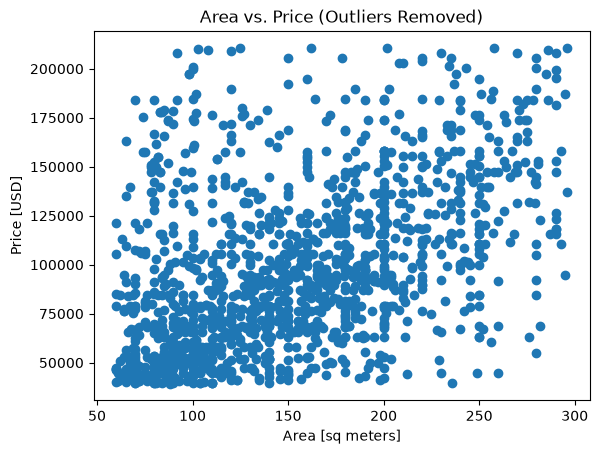

In [13]:
# Define cutoff percentages
lower_cut = 0.05  # Remove bottom 5%
upper_cut = 0.90  # Keep up to 90th percentile

# Filter the data
df_clean = (
    df[
        (df["price_usd"] > df["price_usd"].quantile(lower_cut)) &
        (df["price_usd"] < df["price_usd"].quantile(upper_cut)) &
        (df["area_m2"] < df["area_m2"].quantile(upper_cut)) # <-- Large area outliers also skew the scatter plot
    ]
)

# Show what changed
print(f"Original: {len(df)} rows")
print(f"Cleaned: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

# Plot
fig, ax = plt.subplots()
ax.scatter(df_clean["area_m2"], df_clean["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price (Outliers Removed)")
plt.show()

> 📊 **After outlier removal — reading the improved scatterplot**
>
> The scatterplot should now show a cloud of points with an upward slope, spread
> more evenly across the plot area.
>
> **What changed:** both axes now stop at the quantile cutoffs rather than at the
> extremes of the file, so the same points occupy more of the figure. Put the two
> plots side by side and compare their axis limits: that difference *is* the effect,
> and it can be modest if the tail of your data was not very long to begin with. The
> printed row counts above tell you exactly how many listings were removed.
>
> **What the cleaned scatterplot reveals:**
> - **Positive relationship:** as area increases, price tends to increase.
> - **Significant scatter:** the cloud is wide, not narrow. Pick any area on the
>   x-axis and look at the vertical spread of prices above it: properties of the same
>   size sell across a broad range. This tells us that area *alone* does not fully
>   explain price. Something else matters (location? property type?).
> - **No obvious curve:** the relationship looks roughly linear in this range, which
>   makes Pearson correlation (Lesson 3) an appropriate measure.
>
> **The three things we accomplished by filtering:**
> 1. **Removed noise** — bottom 5% likely contains data errors (implausibly cheap
>    properties); top 10% are luxury outliers that distort the trend.
> 2. **Revealed the pattern** — the main market cluster is now visible and readable.
> 3. **Prepared for modeling** — any future regression model will learn from the
>    "typical" market rather than being pulled by extreme values.

**Cleaned vs raw: what each version of the scatterplot shows and why you need both**

It can be tempting to show only the cleaned scatterplot — it looks better and
communicates more clearly. But the raw scatterplot is equally valuable and should
never be silently discarded:

**The raw scatterplot shows:**
- The true extent of the data: how extreme the extremes actually are. The largest
  property and the highest price in the raw plot are genuinely in the dataset.
  These are facts about the market that have meaning, even if they distort the
  visualization of the main cluster.
- Where data quality issues likely lurk: the few data points far below the main
  cluster on the y-axis (very cheap properties) may be data entry errors — a
  missing zero, a price recorded in thousands rather than units. The raw plot
  makes these suspicious points visible for manual inspection.
- The full market structure: in some analyses, the luxury segment and the mass
  market are both objects of study. A real estate firm's research team might
  specifically want to understand how the luxury end behaves. Filtering it out
  before sharing the raw plot would remove evidence they need.

**The cleaned scatterplot shows:**
- The relationship in the "typical" market — the 85–95% of listings that
  represent the everyday buyer's experience. This is what a median-income buyer,
  a policy analyst studying affordability, or a typical machine learning model
  needs to see.
- Heteroscedasticity and noise patterns that were hidden by compression. You
  can now see that at 150 m², there is still substantial unexplained price
  variation — which tells you that area alone is insufficient to predict price.
- A relationship that is ready for regression analysis. The compressed raw
  scatterplot would produce a meaningless regression line dominated by outliers.

**Best practice:** Always produce both versions. Label the raw one "including
outliers" and the cleaned one "core market (5th–90th percentile)". Explain your
cutoffs and why you chose them. Never filter silently.

---

✅ You can take **Multiple Choice Question 1.2.4.1**

---

### 4.3 Visualizing the Trend: Seaborn's `regplot`

Matplotlib's `scatter` shows the points; it does not fit a line. We need a
regression line — the line of best fit that summarizes the average relationship
between x and y. **Seaborn** makes this effortless with `sns.regplot()`.

> 💡 **What is Seaborn?**
>
> Seaborn is a statistical data visualization library built on top of Matplotlib.
> It adds statistical modeling (regression, distribution fitting) and more
> aesthetically refined defaults, while still using Matplotlib's Figure/Axes
> architecture underneath. You can always pass `ax=ax` to a Seaborn function to
> draw on a specific Axes object — which is exactly how we integrate it with the
> explicit interface.

**Code 1.2.4.3** — Trendline using `sns.regplot`:


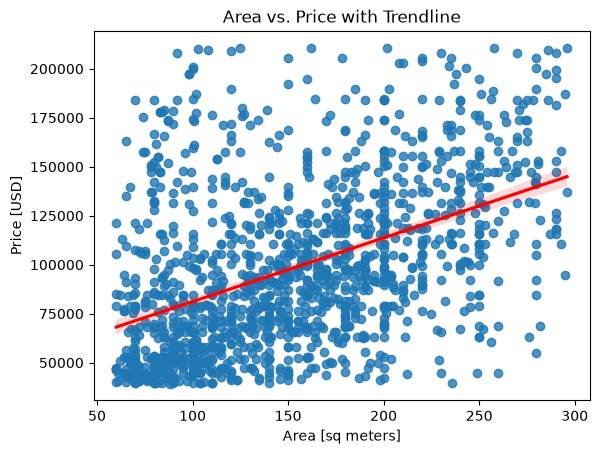

In [14]:
# remember to import your library if you haven't
import seaborn as sns

# Create figure and axis explicitly
fig, ax = plt.subplots()

# Use Seaborn to plot scatter + trendline
sns.regplot(
    data=df_clean, 
    x="area_m2", 
    y="price_usd", 
    line_kws={"color": "red"},  # Make the line distinct
    ax=ax  # Pass the axis to seaborn
)

ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price with Trendline")
plt.show()

> 📊 **Reading the `sns.regplot` output — slope, confidence band, and heteroscedasticity**
>
> **The red line (regression line):**
> The line of best fit slopes upward — confirming a positive relationship between
> area and price. As property size increases, price tends to increase.
>
> **The shaded band (confidence interval):**
> The shaded region around the line is the 95% confidence band. It shows where the
> "true" regression line likely falls, given the sample of data we have. A **narrow
> band** means the line is precisely estimated — there is little uncertainty about
> the slope. A **wide band** means high uncertainty.
>
> For this dataset, the band is wide — especially at the high end of the x-axis.
> This is telling you that the regression line's position is not very certain for
> large properties, because there are fewer of them and they are more variable.
>
> **Heteroscedasticity:**
> Notice that the spread of the points *increases* as area increases. At 50 m²,
> prices cluster tightly. At 200 m², prices span a much wider range. This pattern
> — where the variance of the outcome increases with the predictor — is called
> **heteroscedasticity** (Greek for "different scatter"). It is extremely common
> in real estate data because large properties are more heterogeneous (a 300 m²
> property could be a modest house in a cheap area or a luxury villa in an expensive one).
>
> **Heteroscedasticity is not a problem here**, because we are not yet running a
> formal regression model. But it is a useful observation: it tells us that area
> is a *better* predictor of price for small properties than for large ones.
>
> **What the slope value tells us:**
> The slope of the line is approximately the average additional price per additional
> square meter. If the slope is roughly 700/m², then in the typical market, one
> extra square meter is associated with 700 more in price. We will compute the
> exact correlation in Lesson 3.

**A concrete numerical example: interpreting the regression slope**

Suppose the fitted regression line through our cleaned scatterplot has the equation:

> **price_usd = 18,000 + 700 × area_m2**

Let's unpack every number in this equation:

- **Intercept ($18,000):** This is the model's predicted price for a property with
  area = 0 m². Of course, no property has zero area — this is extrapolation beyond
  the data range and should not be interpreted literally. In a linear model, the
  intercept is primarily a mathematical anchor for the line, not a meaningful real-
  world quantity. You might loosely interpret it as "fixed location value" — the
  price floor before any square meters are added.

- **Slope ($700/m²):** For every one additional square meter of area, the model
  predicts an additional 700 in price, *on average*. This is the core interpretable
  result.

  - A 100 m² property: 18,000 + 700×100 = **88,000** predicted price.
  - A 120 m² property: 18,000 + 700×120 = **102,000** predicted price.
  - The difference between 100 m² and 120 m²: 700 × 20 = **14,000**.

- **The "on average" caveat is critical:** the slope of 700/m² does not mean every
  extra square meter adds exactly 700. It means that *in the aggregate*, across all
  properties in our cleaned dataset, the typical relationship follows this rate. Any
  individual property may deviate substantially. A 120 m² apartment in Polanco (prime
  DF) might sell for $250,000, while a 120 m² house in a rural state might sell for
  60,000. Both can coexist with an average slope of 700/m² — the slope describes
  the central tendency, not individual cases.

- **The confidence band translates the slope's uncertainty:** If the 95% confidence
  band around the slope runs from roughly 500/m² to 900/m², then we are 95%
  confident the "true" slope (in the population of all Mexican properties, not just
  our sample) lies in that range. A narrow band means the slope is precisely estimated;
  a wide band means we have substantial uncertainty. In our dataset, the wide band
  at large property sizes tells us the slope estimate is less reliable for large
  properties — consistent with fewer data points and more variability in that region.

## 5. The Influence of Location (Small Multiples)

We have established that **size affects price** — the scatterplot shows a clear
upward slope. But the *strength* of that relationship might vary dramatically by
location. Does a 100 m² house cost the same in Distrito Federal as in Yucatán?
And beyond price, does the relationship between size and price follow the same
pattern in different states?

To answer this, we first need to understand which states have the highest prices —
and then we can compare the size-price relationship across locations.


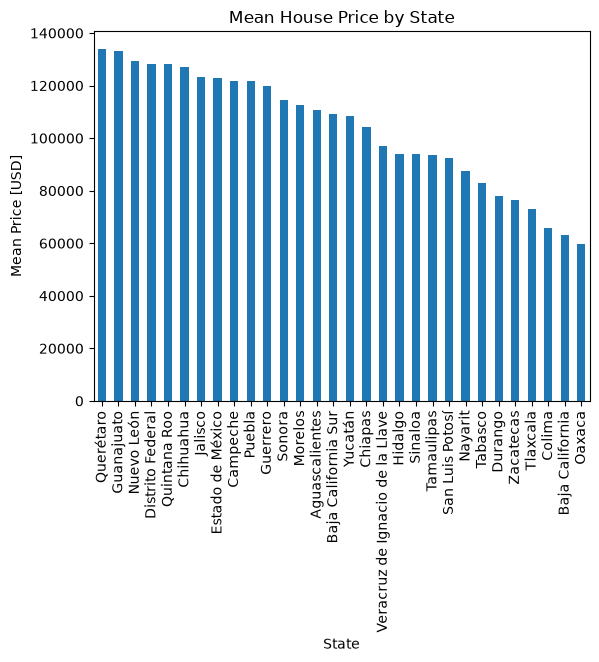

In [16]:
# Aggregate data using groupby
mean_price_by_state = (
    df.groupby("state")["price_usd"]  # <-- "state" & "price_usd"
    .mean()
    .sort_values(ascending=False) # <-- pass in True or False to sort
)

# Create figure and axes explicitly
fig, ax = plt.subplots()

# Use pandas plot method with explicit axes
mean_price_by_state.plot(
    kind="bar",
    ax=ax  # Pass the axes to pandas
)

# Customize using Matplotlib methods
ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.set_title("Mean House Price by State")

plt.show()

> 📊 **Reading the bar chart — price hierarchy across states**
>
> The bar chart should show Distrito Federal with the tallest bar (highest mean
> price), with other states arranged from highest to lowest. This confirms the
> location effect: geography matters.
>
> **Limitation of this chart:** it shows only the mean — which, as we know from
> Lesson 1, is pulled by outliers. A better measure would be the median. We will
> use the median in Lesson 4 when we compute the full location analysis. For now,
> the bar chart gives us a directionally correct ranking.

> 💡 **`groupby()` as split-apply-combine**
>
> The `.groupby()` call above does three things in one line:
>
> 1. **Split** — divides the DataFrame into groups, one for each unique value in
>    `"state"` (e.g., one group for Distrito Federal, one for Yucatán, etc.)
> 2. **Apply** — computes the aggregation function (`.mean()`) independently on
>    each group
> 3. **Combine** — assembles the per-group results back into a single Series,
>    indexed by state name
>
> This three-step **split-apply-combine** pattern is the backbone of all grouped
> analysis in pandas. The same pattern works with `.median()`, `.std()`, `.count()`,
> and any custom aggregation function you define.
>
> **Pandas `.plot()` on a Series:**
> After `groupby + mean + sort_values`, the result is a pandas Series. Calling
> `.plot(kind="bar", ax=ax)` on a Series plots the index (state names) on the
> x-axis and the values (mean prices) on the y-axis — automatically.
>
> **The `ax=ax` connection:**
> Creating `fig, ax = plt.subplots()` first and then passing `ax=ax` to
> `.plot()` ensures that pandas draws on *our specific axes object*, not on a
> new hidden figure. This is the "best of both worlds" pattern: pandas handles
> the data → Matplotlib handles the labels and customization.

**Split-apply-combine: a worked example step by step**

The `.groupby()` pattern is so fundamental that it is worth tracing through a
concrete worked example with small, inspectable data before applying it to our
full dataset.

Suppose we have a toy DataFrame:

```python
import pandas as pd
toy = pd.DataFrame({
    "state":     ["DF", "DF", "DF", "YUC", "YUC", "MEX"],
    "price_usd": [120000, 90000, 150000, 70000, 80000, 100000]
})
```

**Step 1 — Split:** `toy.groupby("state")` divides the DataFrame into three groups:
- Group "DF": rows with price 120,000, 90,000, 150,000
- Group "MEX": row with price 100,000
- Group "YUC": rows with price 70,000, 80,000

No computation happens yet. The groupby object is just an instruction: "split
along the `state` column when I ask you to compute something."

**Step 2 — Apply:** Chaining `.mean()` after `.groupby("state")` applies the mean
function *independently* to each group:
- "DF" mean: (120,000 + 90,000 + 150,000) / 3 = **120,000**
- "MEX" mean: 100,000 / 1 = **100,000**
- "YUC" mean: (70,000 + 80,000) / 2 = **75,000**

**Step 3 — Combine:** pandas assembles the three results into a single Series:

```
state
DF     120000.0
MEX    100000.0
YUC     75000.0
Name: price_usd, dtype: float64
```

The index is the group key (state name); the values are the per-group means.

**The power of this pattern:** By substituting `.mean()` with any other function,
you can compute different statistics:
- `.median()` — median price per state (more robust than mean for skewed data)
- `.std()` — price standard deviation per state (how variable is each market?)
- `.count()` — number of listings per state (which states are over/under-represented?)
- `.corr()` — correlation matrix per state (which we do in Lesson 3)

The split-apply-combine pattern is so general that it covers virtually all grouped
analysis you will ever need to do in pandas.

### 5.2 Small Multiples: Size vs Price by Location

Now that we know which states are most expensive overall, let's examine whether
the *relationship* between size and price is consistent across locations. This is
a fundamentally different question from "which state is expensive?" — it is asking
"does size *explain* price equally well everywhere?"

> 🎯 **What are small multiples?**
>
> Small multiples (also called facets or panel charts) are a grid of charts where
> each panel shows the same type of visualization for a different subgroup. The
> axes are aligned across panels so differences in slope, intercept, and scatter
> are immediately visible.
>
> **When to use small multiples:**
> - When you have a numerical-numerical relationship (scatterplot) and want to see
>   if it differs across categories (states, property types, years)
> - When a single plot with multiple colors would be too cluttered to read
> - When the comparison across panels is more informative than the individual panels
>
> In Matplotlib, we create small multiples by calling `plt.subplots(nrows, ncols)`,
> which returns a grid of Axes objects we loop through.

**Code Task 1.2.5.2**: Create small multiples — one scatterplot per state:


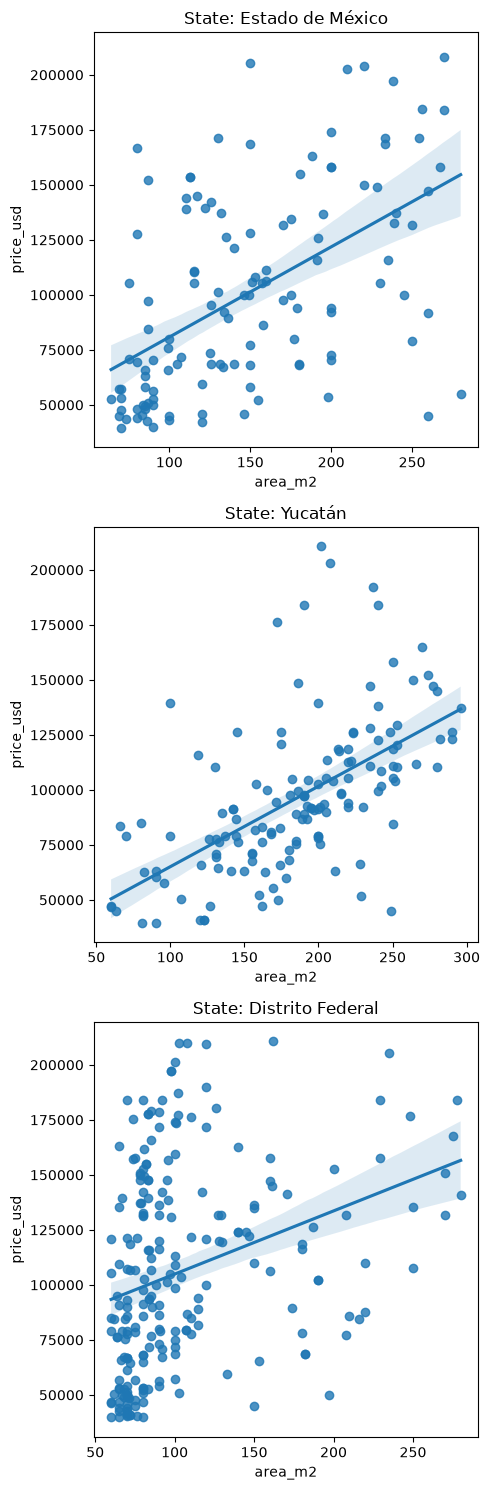

In [17]:
## 1. Create your custom figure and axes
fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharey=True)

# 2. Create a list of the top 3 states
top_states = selected_states  # <--- pass selected_states

# 3. Filter df_clean to include only these states
df_states = df_clean[df_clean["state"].isin(top_states)]

# 4. Loop through the states and plot on each specific axis
states = df_states["state"].unique()

for ax, state in zip(axes, states):
    # Filter data for the current state
    subset = df_states[df_states["state"] == state]
    
    # Use regplot (Axes-level) which ACCEPTS 'ax='
    sns.regplot(
        data=subset,
        x="area_m2",  # <--- "area_m2"
        y="price_usd",  # <--- "price_usd" 
        color='tab:blue', # Optional: keep colors consistent
        ax=ax # <--- This is where you pass the axis explicitly
    )
    
    ax.set_title(f"State: {state}")

plt.tight_layout()
plt.show()

> 📊 **Reading the small multiples — how location changes the size-price relationship**
>
> Three plots, same two variables, three very different stories:

**Estado de México — moderate positive relationship:**

- The regression line rises at a clear angle — area does predict price here.
- Wide confidence band — the relationship is real but imprecise. Many properties
  deviate substantially from the line.
- Several high-price properties sit well above the line, suggesting other factors
  (proximity to Mexico City? Specific neighborhoods?) drive premiums.

**Yucatán — strongest and most consistent relationship:**

- Narrow confidence band — the regression line is estimated with high precision.
  The relationship between size and price is more predictable here than in the
  other two states.
- Points cluster more tightly around the line.
- Interpretation: in Yucatán, size is a stronger predictor of price than elsewhere.

**Distrito Federal — weakest relationship:**

- Notice the **compression on the x-axis** — most properties cluster between
  60–120 m². In Mexico City, land is expensive and apartments dominate, so large
  properties are genuinely rare.
- The regression line is nearly flat, and the confidence band is wide — size
  barely explains price in Distrito Federal.
- Interpretation: in Mexico City, **price depends more on location within the city
  (neighborhood, floor, view, proximity to transit) than on raw size.** A 100 m²
  apartment in Polanco is worth far more than a 100 m² apartment in the periphery.

> 💡 **The confidence band width is as important as the slope:**
>
> | Observation | Implication |
> |---|---|
> | **Steep slope + narrow band** | Strong, reliable size-price relationship |
> | **Steep slope + wide band** | Size predicts direction but not magnitude precisely |
> | **Flat slope + wide band** | Size barely explains price — other factors dominate |
>
> Distrito Federal falls into the third category. This is the most important result
> of this lesson: **location changes not just the price level, but how well size
> predicts price.**

> 🧠 **Key insight connecting to Lesson 3:**
>
> A single correlation coefficient computed on the *entire* dataset merges three
> very different relationships into one number. In Yucatán, size-price correlation
> might be 0.75. In Distrito Federal, it might be 0.30. The national average could
> be 0.55 — a number that describes *neither* market accurately. This is an example
> of **Simpson's Paradox** (or more precisely, **ecological fallacy**), which we
> will study formally in Lesson 3 when we compute segmented correlations.

**The confidence band as a sample-size signal**

Beyond indicating slope uncertainty, the width of the confidence band carries
a second message: it tells you how much data supports the estimate at each
point along the x-axis. Understanding this turns the band from a decorative
shading into a diagnostic tool.

**Why the band widens at the extremes:** The regression line is fitted to all
the data simultaneously, so it is most precisely estimated where the data is
densest. In our three-state plot:
- For Yucatán and Estado de México, most properties cluster between 60–150 m².
  The band is narrowest in this range — many data points are constraining the
  line's position.
- As area increases toward 200–250 m², fewer properties exist. With fewer points
  to anchor the line, the model becomes less certain about where the line should
  sit. The band widens to communicate this uncertainty honestly.
- At the far right edge of each plot, the band may be extremely wide — there
  could be just one or two properties at those sizes. A single property at 300 m²
  can drag the line significantly, but the wide band tells you not to trust that
  estimate.

**Practical reading rules for the confidence band:**

| Band width | Interpretation | Action |
|---|---|---|
| **Narrow throughout** | Consistent data density; reliable relationship | Trust the slope; report it with confidence |
| **Wide at the edges, narrow in the center** | Normal pattern; dense center, sparse tails | Focus interpretation on the central range |
| **Wide throughout** | Too few data points overall | Report the slope cautiously; get more data |
| **Wider in one state than another (same x-range)** | Fewer listings in that state | Compare listing counts before comparing slopes |

**For Distrito Federal specifically:** the nearly flat line with a wide band is
not just telling you the slope is near zero — it is telling you that the few
large properties in DF are scattered wildly in price, giving the model almost
no information about whether size matters there. The flat slope and the wide band
reinforce each other: size doesn't seem to matter, and we don't have enough data
to be sure either way.

---

✅ You can take **Multiple Choice Question 1.2.5.1**

---


# Wrap-up

Visualization transformed the summary statistics from Lesson 1 into genuine
understanding. Here is what this lesson established:

- **Always use Matplotlib's explicit (object-oriented) interface:** `fig, ax =
  plt.subplots()` then `ax.method()`. This keeps your axes objects accessible,
  integrates seamlessly with Seaborn and Pandas `.plot()`, and scales to complex
  multi-panel layouts. The implicit interface (`plt.plot()`, `plt.title()`) works
  for quick single plots in an interactive session, but it breaks down as soon as
  you add a second subplot or try to pass the axes to Seaborn. Building the
  explicit habit from the start means you will never have to rewrite your plotting
  code when your analysis becomes more complex.

- **Histograms reveal distribution shape:** Both `price_usd` and `area_m2` are
  right-skewed — a small number of expensive or large properties pull the mean
  above the median. For comparing groups, use the **median**, not the mean.
  Right skew also signals that log transformation may improve downstream modeling,
  that outlier removal should be applied before regression, and that the choice of
  bin width in a histogram matters: too few bins and you miss the tail structure;
  too many and you mistake random noise for meaningful peaks. The default of 10
  bins is a starting point — always adjust based on what you are trying to
  communicate.

- **Boxplots enable group comparison:** The five-number summary (Q1, median, Q3,
  whiskers, outliers) in a compact format that scales to many groups. The key
  finding: apartments and houses have similar *total* prices but very different
  value *per square meter* — a distinction that requires the `price_per_m2`
  feature we will build in Lesson 4. The state-level boxplot went further: it
  showed that Distrito Federal commands a price premium with high internal
  variability (wide IQR), Yucatán is affordable and consistent (narrow IQR), and
  Estado de México sits in between. These are not just descriptive facts — they
  are evidence about market structure that guides every analytical decision in the
  lessons that follow.

- **Quantile-based outlier removal:** Remove bottom 5% and top 10% based on the
  data's own percentiles — not a fixed threshold. Apply the cutoff to *all* axes
  in a scatterplot, not just the y-axis. The key insight is that quantile cuts are
  *relative* — they adapt to the scale and distribution of each specific dataset,
  making your code reusable across different markets and time periods. A fixed
  cutoff of "$250,000" would fail on a dataset from a different city or year. The
  quantile approach always removes "the most extreme 10%" regardless of what dollar
  amount that corresponds to.

- **Small multiples expose hidden heterogeneity:** The size-price relationship
  looks very different in Distrito Federal (flat, noisy) vs Yucatán (steep,
  consistent). A single national correlation coefficient would hide this entirely.
  Small multiples are the most powerful tool in the data scientist's visualization
  kit for detecting this kind of heterogeneity. The visual comparison across panels
  — aligned axes, same plot type — lets the human visual system do the comparison
  work instantly. What would take a table of 20 numbers to communicate takes a
  glance across a 4-panel grid. This is why data scientists always ask: "before
  I report this aggregate number, does it look the same in every subgroup?"

> ⚠️ **What visualization cannot do:** Visual patterns are suggestive but not
> precise. We cannot tell from a scatterplot *exactly* how correlated size and
> price are, or whether the difference between states is statistically significant.
> For that, we need formal correlation analysis. Visualization tells you where to
> look; statistics tells you whether what you see is real. Always use both.

➡️ **In Lesson 3 (Correlation)**, we will compute Pearson correlation coefficients,
build a correlation heatmap, and investigate Simpson's Paradox — the striking
phenomenon where a relationship that appears strong across all data disappears
(or even reverses) when you break the data apart by group. The visual evidence
from this lesson — especially the dramatically different slopes in the three-state
small multiples — is exactly what motivates the segmented correlation analysis
in Lesson 3. Every number we compute there will have a visual counterpart you have
already seen here.
